In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, classification_report, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

### Load Data

In [13]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


### Train-test split

In [14]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

# TabNet

In [15]:
# Convert to numpy and float32
X_train = X_train.values.astype(np.float32) if isinstance(X_train, pd.DataFrame) else X_train.astype(np.float32)
X_test = X_test.values.astype(np.float32) if isinstance(X_test, pd.DataFrame) else X_test.astype(np.float32)
y_train = y_train if isinstance(y_train, np.ndarray) else np.array(y_train)
y_test = y_test if isinstance(y_test, np.ndarray) else np.array(y_test)

In [16]:

# Initialize TabNetClassifier
tabnet = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=1,
    seed=42
)

# Fit the model
tabnet.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_test, y_test)],
    eval_name=['valid'],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)


c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.70497 | valid_accuracy: 0.52644 |  0:00:00s
epoch 1  | loss: 0.67012 | valid_accuracy: 0.58709 |  0:00:00s
epoch 2  | loss: 0.65799 | valid_accuracy: 0.63375 |  0:00:01s
epoch 3  | loss: 0.64579 | valid_accuracy: 0.62131 |  0:00:02s
epoch 4  | loss: 0.61118 | valid_accuracy: 0.59953 |  0:00:02s
epoch 5  | loss: 0.56153 | valid_accuracy: 0.63142 |  0:00:02s
epoch 6  | loss: 0.5421  | valid_accuracy: 0.62986 |  0:00:03s
epoch 7  | loss: 0.53596 | valid_accuracy: 0.65941 |  0:00:04s
epoch 8  | loss: 0.52368 | valid_accuracy: 0.66174 |  0:00:04s
epoch 9  | loss: 0.51997 | valid_accuracy: 0.70373 |  0:00:05s
epoch 10 | loss: 0.51687 | valid_accuracy: 0.65086 |  0:00:05s
epoch 11 | loss: 0.52226 | valid_accuracy: 0.71462 |  0:00:06s
epoch 12 | loss: 0.5091  | valid_accuracy: 0.70762 |  0:00:06s
epoch 13 | loss: 0.51213 | valid_accuracy: 0.73095 |  0:00:07s
epoch 14 | loss: 0.51008 | valid_accuracy: 0.7395  |  0:00:07s
epoch 15 | loss: 0.50869 | valid_accuracy: 0.74728 |  0

c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [17]:
y_pred = tabnet.predict(X_test)
print(f'Classification Report: \n{classification_report(y_test, y_pred)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.78      0.79      0.78       707
           1       0.74      0.72      0.73       579

    accuracy                           0.76      1286
   macro avg       0.76      0.75      0.76      1286
weighted avg       0.76      0.76      0.76      1286




In [18]:
y_probas = tabnet.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.8241590377970958


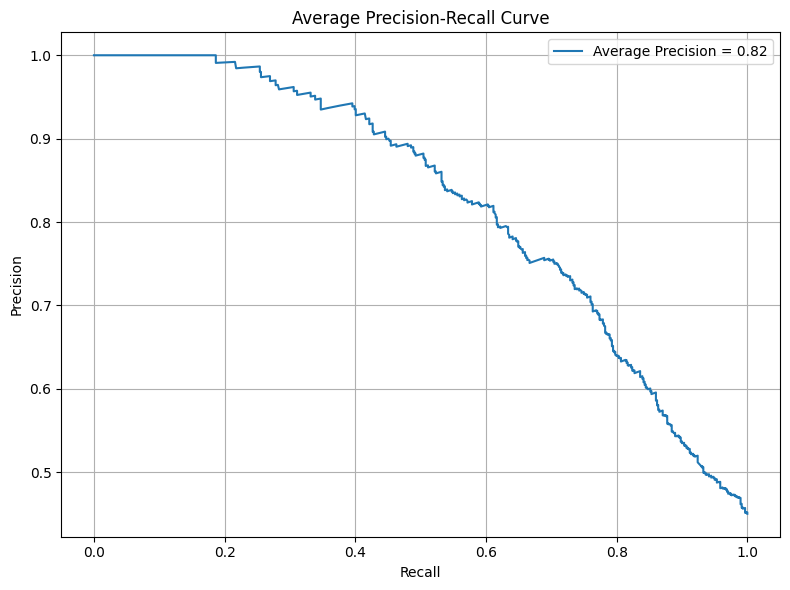

In [19]:
# Compute precision-recall curve and average precision
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)
avg_precision = average_precision_score(y_test, y_probas)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Average Precision = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Average Precision-Recall Curve')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [23]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, recall_score
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import numpy as np

class TabNetWrapper(TabNetClassifier):
    def fit(self, X, y):
        if hasattr(X, "values"):
            X = X.values
        if hasattr(y, "values"):
            y = y.values
        X = X.astype(np.float32)
        y = y.astype(int)

        return super().fit(
            X, y,
            eval_set=[(X, y)],
            eval_name=['valid'],
            eval_metric=['accuracy'],
            max_epochs=100,
            patience=10,
            batch_size=256,
            virtual_batch_size=128
        )


# 2. Define parameter grid
param_dist = {
    'n_d': [8, 16, 32],
    'n_a': [8, 16, 32],
    'n_steps': [3, 5],
    'gamma': [1.0, 1.3],
    'lambda_sparse': [0.0001, 0.001],
    'momentum': [0.02, 0.1],
    'optimizer_params': [{'lr': 0.01}, {'lr': 0.02}],
}

# 3. Make sure original X, y are numpy arrays
X = X.values.astype(np.float32) if hasattr(X, "values") else X.astype(np.float32)
y = y.values if hasattr(y, "values") else y

# 4. Set up cross-validation
# skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

tabnet_search = RandomizedSearchCV(
    estimator=TabNetWrapper(
        optimizer_fn=torch.optim.Adam,
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params={"step_size": 10, "gamma": 0.9},
        verbose=0,
        seed=42,
        device_name='cuda'  # <-- ENABLE GPU
    ),
    param_distributions=param_dist,
    scoring=make_scorer(recall_score),
    cv=10,
    n_iter=10,
    verbose=2,
    n_jobs=1,
    error_score='raise'
)


# 6. Run the search
tabnet_search.fit(X, y)


Fitting 10 folds for each of 10 candidates, totalling 100 fits

Early stopping occurred at epoch 37 with best_epoch = 27 and best_valid_accuracy = 0.75272


c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


[CV] END gamma=1.3, lambda_sparse=0.001, momentum=0.1, n_a=32, n_d=32, n_steps=5, optimizer_params={'lr': 0.01}; total time= 2.5min

Early stopping occurred at epoch 53 with best_epoch = 43 and best_valid_accuracy = 0.77208


c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


[CV] END gamma=1.3, lambda_sparse=0.001, momentum=0.1, n_a=32, n_d=32, n_steps=5, optimizer_params={'lr': 0.01}; total time= 1.9min

Early stopping occurred at epoch 36 with best_epoch = 26 and best_valid_accuracy = 0.76464


...

c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


[CV] END gamma=1.3, lambda_sparse=0.0001, momentum=0.02, n_a=16, n_d=8, n_steps=5, optimizer_params={'lr': 0.01}; total time=  31.5s

Early stopping occurred at epoch 55 with best_epoch = 45 and best_valid_accuracy = 0.75376


c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


[CV] END gamma=1.3, lambda_sparse=0.0001, momentum=0.02, n_a=16, n_d=8, n_steps=5, optimizer_params={'lr': 0.01}; total time=  56.2s


KeyboardInterrupt: 

In [ ]:
best_model = tabnet_search.best_estimator_
y_pred = best_model.predict(X_test.astype(np.float32))
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.7567    0.8798    0.8136       707
           1     0.8168    0.6546    0.7267       579

    accuracy                         0.7784      1286
   macro avg     0.7868    0.7672    0.7702      1286
weighted avg     0.7838    0.7784    0.7745      1286



In [ ]:
y_probas = best_model.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

In [ ]:
from sklearn.metrics import roc_auc_score

# Assuming you have predictions as probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]  # Probability of class 1
auc = roc_auc_score(y_test, y_prob)
print(f"AUC: {auc:.4f}")

In [ ]:
import numpy as np
from sklearn.utils import resample

n_bootstraps = 1000
rng_seed = 42
bootstrapped_scores = []

np.random.seed(rng_seed)
for _ in range(n_bootstraps):
    indices = resample(np.arange(len(y_test)))
    if len(np.unique(y_test[indices])) < 2:
        continue  # skip if only one class in the sample
    score = roc_auc_score(y_test[indices], y_prob[indices])
    bootstrapped_scores.append(score)

# 95% CI
sorted_scores = np.array(bootstrapped_scores)
sorted_scores.sort()
ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]

print(f"AUC: {auc:.4f}, 95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")


In [ ]:
from sklearn.metrics import cohen_kappa_score

# For predicted labels (not probabilities)
y_pred = best_model.predict(X_test)
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.4f}")
